## NRI Data Check
Access Data from past and current versions (2020,2021,2023,2025)\
Identify and isolate relevant columns, basic exploration, generate summary score for YoY risk index


In [1]:
import pandas as pd
from arcgis.features import FeatureLayer
import urllib3
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pytest
import seaborn as sns
import cpi
cpi.update()
import datetime as dt

## Switch to read .csv if needed (saved from previous version on github)

# 1. Suppress SSL Warnings
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.simplefilter("ignore", UserWarning)

def fetch_nri_by_url(service_url, version_label):
    """
    Fetches data directly via REST URL to bypass Item ID retirement issues.
    """
    print(f"Connecting to {version_label}...")
    try:
        # Initialize the layer directly from the URL
        # We set verify_cert=False to stop the SSL noise in restricted environments
        layer = FeatureLayer(service_url)
        
        # Query the data. We use 'out_fields="*"' to get all columns.
        # We also request result_type='standard' to help with the decompression issue.
        query_result = layer.query(where="1=1", out_fields="*", return_geometry=False)
        
        # Convert to DataFrame
        df = query_result.sdf
        
        # Clean up column names (ArcGIS sometimes adds extra prefixes)
        df.columns = [c.upper() for c in df.columns]
        
        print(f"Successfully imported {len(df)} records for {version_label}.")
        return df
    except Exception as e:
        print(f"Failed to fetch {version_label}: {e}")
        return None

# --- REST Service URLs (Updated for 2020-2023 Snapshots) ---
# Note: These URLs point to the persistent FeatureServer endpoints 
# managed by FEMA or the Resilience/Climate Hubs.

urls = {
    "2020_v1_17": "https://services.arcgis.com/XG15cJAlne2vxtgt/arcgis/rest/services/NRI_Counties_v117/FeatureServer/0",
    "2021_v1_18": "https://services.arcgis.com/XG15cJAlne2vxtgt/arcgis/rest/services/NRI_Counties_Prod_v1181_view/FeatureServer/0",
    "2023_v1_19": "https://services.arcgis.com/XG15cJAlne2vxtgt/arcgis/rest/services/National_Risk_Index_Counties_(March_2023)/FeatureServer/0",
    "2025_v1_20": "https://services.arcgis.com/XG15cJAlne2vxtgt/arcgis/rest/services/National_Risk_Index_Counties/FeatureServer/0"
}

# --- Import Data ---
nri_2020 = fetch_nri_by_url(urls["2020_v1_17"], "NRI 2020 (v1.17)")
nri_2021 = fetch_nri_by_url(urls["2021_v1_18"], "NRI 2021 (v1.18)")
nri_2023 = fetch_nri_by_url(urls["2023_v1_19"], "NRI 2023 (v1.19)")
nri_2025 = fetch_nri_by_url(urls["2025_v1_20"], "NRI 2025 (v1.20)")

pd.set_option('display.max_columns', 50)
pd.options.display.float_format = '{:,.2f}'.format

/var/folders/pz/bg9vnbfd2lx6cs0yw9q7vc3w0000gn/T/ipykernel_16872/2343719463.py:9: StaleDataWarning: CPI data is out of date. To accurately inflate to today's dollars, you must run `cpi.update()`.
  import cpi
/opt/anaconda3/envs/env207/lib/python3.10/site-packages/cpi/download.py:175: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(io.StringIO(response.text), sep="\t")
/opt/anaconda3/envs/env207/lib/python3.10/site-packages/cpi/download.py:175: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(io.StringIO(response.text), sep="\t")
/opt/anaconda3/envs/env207/lib/python3.10/site-packages/cpi/download.py:175: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(io.StringIO(response.text), sep="\t")
/opt/anaconda3/envs/env207/lib/python3.10/site-packages/cpi/download.py:175: DtypeW

Connecting to NRI 2020 (v1.17)...
Successfully imported 3142 records for NRI 2020 (v1.17).
Connecting to NRI 2021 (v1.18)...
Successfully imported 3142 records for NRI 2021 (v1.18).
Connecting to NRI 2023 (v1.19)...
Successfully imported 3231 records for NRI 2023 (v1.19).
Connecting to NRI 2025 (v1.20)...
Successfully imported 3232 records for NRI 2025 (v1.20).


## Columns of interest:
Keeping these columns and removing the various columns for each disaster type

In [2]:
keep_cols_1 = ['NRI_ID',
            'STATEABBRV',
            'STATEFIPS',
            'COUNTYFIPS', 
             'COUNTY', 
             'POPULATION', 
             'BUILDVALUE', 
             'AGRIVALUE', 
             'AREA', 
             'RISK_SCORE', 
             'RISK_RATNG', 
             'RISK_NPCTL', 
             'EAL_SCORE', 
             'EAL_VALT', 
             'EAL_NPCTL', 
             'EAL_RATNG', 
             'SOVI_SCORE', 
             'SOVI_RATNG', 
             'SOVI_VALUE', 
             'RESL_SCORE', 
             'RESL_RATNG', 
             'RESL_VALUE']

keep_cols_2 = ['NRI_ID',
               'STATEABBRV',
               'STATEFIPS',
            'COUNTYFIPS',  
             'COUNTY', 
             'POPULATION', 
             'BUILDVALUE', 
             'AGRIVALUE', 
             'AREA',
             'RISK_VALUE', 
             'RISK_SCORE', 
             'RISK_RATNG', 
             'EAL_SCORE', 
             'EAL_VALT',  
             'EAL_RATNG', 
             'SOVI_SCORE', 
             'SOVI_RATNG',  
             'RESL_SCORE', 
             'RESL_RATNG', 
             'RESL_VALUE',
             'CRF_VALUE']

nri_20 = nri_2020[keep_cols_1]
nri_20.columns = nri_20.columns.str.lower()

nri_21 = nri_2021[keep_cols_1]
nri_21.columns = nri_21.columns.str.lower()

nri_23 = nri_2023[keep_cols_2]
nri_23.columns = nri_23.columns.str.lower()

nri_25 = nri_2025[keep_cols_2]
nri_25.columns = nri_25.columns.str.lower()

print('Shapes:\n'+'='*50)
print('2020', nri_20.shape)
print('2021', nri_21.shape)
print('2023', nri_23.shape)
print('2025', nri_25.shape)

Shapes:
2020 (3142, 22)
2021 (3142, 22)
2023 (3231, 21)
2025 (3232, 21)


## Missing Values- Territories 

In [3]:
print("\nMissing values total 2020")
print(nri_20.isna().sum().sum())
print("\nMissing values total 2021")
print(nri_21.isna().sum().sum())
print("\nMissing values total 2023")
print(nri_23.isna().sum().sum())
print("\nMissing values total 2025")
print(nri_25.isna().sum().sum())



Missing values total 2020
0

Missing values total 2021
0

Missing values total 2023
450

Missing values total 2025
528


23 and 25 missing data for 88 rows which appear to be territories

In [4]:
nri_25[nri_25["crf_value"].isna()].stateabbrv.value_counts()

stateabbrv
PR    78
AS     3
MP     3
VI     3
GU     1
Name: count, dtype: Int64

In [5]:
nri_25[(nri_25["crf_value"].notna()) & (nri_25["stateabbrv"].isin(["PR","AS","MP","VI","GU"]))]

,nri_id,stateabbrv,statefips,countyfips,county,population,buildvalue,agrivalue,area,risk_value,risk_score,risk_ratng,eal_score,eal_valt,eal_ratng,sovi_score,sovi_ratng,resl_score,resl_ratng,resl_value,crf_value


In [6]:
nri_25 = nri_25.drop(nri_25[nri_25.stateabbrv.isin(["PR","AS","MP","VI","GU"])].index)
nri_23 = nri_23.drop(nri_23[nri_23.stateabbrv.isin(["PR","AS","MP","VI","GU"])].index)

print('2020', nri_20.shape)
print('2021', nri_21.shape)
print('2023',nri_23.shape)
print('2025',nri_25.shape)

2020 (3142, 22)
2021 (3142, 22)
2023 (3143, 21)
2025 (3144, 21)


In [7]:
# Recheck NaNs

print("\nMissing values total 2020")
print(nri_20.isna().sum().sum())
print("\nMissing values total 2021")
print(nri_21.isna().sum().sum())
print("\nMissing values total 2023")
print(nri_23.isna().sum().sum())
print("\nMissing values total 2025")
print(nri_25.isna().sum().sum())


Missing values total 2020
0

Missing values total 2021
0

Missing values total 2023
0

Missing values total 2025
0


## Change in Methodology
FEMA changed the NRI methodology in 2023. To enable comparison, we reconstructed 2020 and 2021 risk values with the current method and performed some tests to ensure the new values were reasonable. We followed the method outlined in sections 3 and 4 of the latest technical documentation: https://www.fema.gov/sites/default/files/documents/fema_national-risk-index_technical-documentation.pdf

  - Apply Probability Point Function- triangular distribution with min 0.5, mode 1, max 2✅
  - Recalculate for 25 to ensure correct methodology✅
  - Sanity check against old score✅
- Arrange multi-year df in friendly format
- calculate (or write funtion) for change over time (takes multiple years, difference between max year value and min year)
- Community resilience score methodology change 25 administration- compare counties to 23, anything obvious
- Interesting correlations: how do we interpret or use zillow data to explore the effect of property prices to risk calculation (commercial vs personal??). Almost a normalization based on property values. physical risk vs monetary. Or understand relationship
2/6
- sovi, resil, crf values to Dave to add to regression
- Investigate massive increase in risk values 23, 25
- Investigate top counties for driving overall stats 

## Community Risk Factor Calc

In [8]:
from scipy import stats

In [9]:
# Get initial ratio from sovi_score / resl_score
nri_20['comm_risk_ratio_score'] = (
    nri_20['sovi_score'] / nri_20['resl_score']
)

#replicate for 21
nri_21['comm_risk_ratio_score'] = (
    nri_21['sovi_score'] / nri_21['resl_score']
)

print("\n" + "="*70)
print("STEP 1: Community Risk Ratio Calculation")
print("="*70)
print(nri_20[['county', 'sovi_score', 
          'resl_score', 'comm_risk_ratio_score']].head())
print(f"\nRatio range: {nri_20['comm_risk_ratio_score'].min():.3f} to "
      f"{nri_20['comm_risk_ratio_score'].max():.3f}")


STEP 1: Community Risk Ratio Calculation
      county  sovi_score  resl_score  comm_risk_ratio_score
0     Kenton       30.51       56.80                   0.54
1        Lee       29.29       48.29                   0.61
2       Lyon       29.92       50.60                   0.59
3  McCracken       42.18       56.57                   0.75
4   Marshall       37.45       57.30                   0.65

Ratio range: 0.000 to 2.069


/var/folders/pz/bg9vnbfd2lx6cs0yw9q7vc3w0000gn/T/ipykernel_16872/915899317.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_20['comm_risk_ratio_score'] = (
/var/folders/pz/bg9vnbfd2lx6cs0yw9q7vc3w0000gn/T/ipykernel_16872/915899317.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_21['comm_risk_ratio_score'] = (


In [10]:
# Convert ratio to national percentile
nri_20['comm_risk_ratio_npctl'] = (
    nri_20['comm_risk_ratio_score'].rank(pct=True, method='average') * 100
)

#replicate for 21
nri_21['comm_risk_ratio_npctl'] = (
    nri_21['comm_risk_ratio_score'].rank(pct=True, method='average') * 100
)

print("\n" + "="*70)
print("STEP 2: National Percentile Ranking")
print("="*70)
print(nri_20[['county', 'comm_risk_ratio_score', 
          'comm_risk_ratio_npctl']].head(10))
print(f"\nPercentile range: {nri_20['comm_risk_ratio_npctl'].min():.1f} to "
      f"{nri_20['comm_risk_ratio_npctl'].max():.1f}")


STEP 2: National Percentile Ranking
       county  comm_risk_ratio_score  comm_risk_ratio_npctl
0      Kenton                   0.54                  19.54
1         Lee                   0.61                  31.16
2        Lyon                   0.59                  28.52
3   McCracken                   0.75                  59.99
4    Marshall                   0.65                  39.88
5       Mason                   0.73                  57.03
6     Menifee                   0.87                  82.05
7    Metcalfe                   0.65                  38.99
8  Montgomery                   0.61                  32.11
9      Oldham                   0.12                   0.38

Percentile range: 0.0 to 100.0


/var/folders/pz/bg9vnbfd2lx6cs0yw9q7vc3w0000gn/T/ipykernel_16872/3273967751.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_20['comm_risk_ratio_npctl'] = (
/var/folders/pz/bg9vnbfd2lx6cs0yw9q7vc3w0000gn/T/ipykernel_16872/3273967751.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_21['comm_risk_ratio_npctl'] = (


In [11]:
# Apply Triangular Distribution PPF (Percent Point Function)
# Input: percentile (0-100), needs to be converted to probability (0-1)

# Define triangular distribution parameters
tri_min = 0.5
tri_mode = 1.0
tri_max = 2.0

# Create the triangular distribution
# scipy.stats.triang requires:
# - c = (mode - min) / (max - min)  # shape parameter
# - loc = min  # location (minimum)
# - scale = max - min  # scale (range)

c = (tri_mode - tri_min) / (tri_max - tri_min)
tri_dist = stats.triang(c=c, loc=tri_min, scale=tri_max - tri_min)

# Apply PPF: convert percentile (0-100) to probability (0-1), then to risk factor
nri_20['comm_risk_factor'] = tri_dist.ppf(
    nri_20['comm_risk_ratio_npctl'] / 100
)

#replicate for 21
nri_21['comm_risk_factor'] = tri_dist.ppf(
    nri_21['comm_risk_ratio_npctl'] / 100
)

print("\n" + "="*70)
print("STEP 3: Community Risk Factor (Triangular PPF)")
print("="*70)
print(nri_20[['county', 'comm_risk_ratio_npctl', 
          'comm_risk_factor']].head(10))
print(f"\nRisk Factor range: {nri_20['comm_risk_factor'].min():.3f} to "
      f"{nri_20['comm_risk_factor'].max():.3f}")


STEP 3: Community Risk Factor (Triangular PPF)
       county  comm_risk_ratio_npctl  comm_risk_factor
0      Kenton                  19.54              0.88
1         Lee                  31.16              0.98
2        Lyon                  28.52              0.96
3   McCracken                  59.99              1.23
4    Marshall                  39.88              1.05
5       Mason                  57.03              1.20
6     Menifee                  82.05              1.48
7    Metcalfe                  38.99              1.04
8  Montgomery                  32.11              0.99
9      Oldham                   0.38              0.55

Risk Factor range: 0.515 to 2.000


/var/folders/pz/bg9vnbfd2lx6cs0yw9q7vc3w0000gn/T/ipykernel_16872/468754994.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_20['comm_risk_factor'] = tri_dist.ppf(
/var/folders/pz/bg9vnbfd2lx6cs0yw9q7vc3w0000gn/T/ipykernel_16872/468754994.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_21['comm_risk_factor'] = tri_dist.ppf(


In [12]:
# Create Risk Value from EAL value * new comm risk factor
nri_20['risk_value'] = nri_20['eal_valt'] * nri_20['comm_risk_factor']

# replicate for 21
nri_21['risk_value'] = nri_21['eal_valt'] * nri_21['comm_risk_factor']

desc20 = nri_20.risk_value.describe()
desc21 = nri_21.risk_value.describe()
desc23 = nri_23.risk_value.describe()
desc25 = nri_25.risk_value.describe()
comp = pd.concat([desc20,desc21,desc23,desc25],axis=1)
comp

/var/folders/pz/bg9vnbfd2lx6cs0yw9q7vc3w0000gn/T/ipykernel_16872/650776256.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_20['risk_value'] = nri_20['eal_valt'] * nri_20['comm_risk_factor']
/var/folders/pz/bg9vnbfd2lx6cs0yw9q7vc3w0000gn/T/ipykernel_16872/650776256.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_21['risk_value'] = nri_21['eal_valt'] * nri_21['comm_risk_factor']


,risk_value,risk_value,risk_value,risk_value
count,"3,142.00","3,142.00","3,143.00","3,144.00"
mean,"11,950,769.22","11,435,135.31","27,840,735.35","51,500,133.49"
std,"45,823,938.27","53,531,219.88","139,416,566.08","219,202,408.27"
min,"18,189.82","5,956.16","35,741.27","54,920.46"
25%,"2,833,267.96","1,842,770.64","3,142,511.62","8,825,243.72"
50%,"4,976,364.06","3,721,500.72","6,290,126.65","16,925,905.01"
75%,"9,816,945.04","7,941,177.24","15,439,705.56","35,591,427.71"
max,"2,067,970,678.15","2,107,594,379.80","5,326,192,908.08","9,180,158,357.60"


Notable increases in the mean, min, median, and max in 23 and 25

In [13]:
# Check accuracy: compare to 23 and 25 risk_value distributions, recreate risk_npctl and compare. 
nri_20['risk_npctl_check'] = (
    nri_20['risk_value'].rank(pct=True, method='average') * 100
)

print("\n" + "="*70)
print("Check Accuracy: risk_npctl vs new nat'l pct based on value calc")
print("="*70)
print(nri_20[['county', 'risk_npctl', 
          'risk_npctl_check']].head(10))
print("\nExisting dist:")
print(nri_20['risk_npctl'].describe())
print("\n Vs Calculated stats:")
print(nri_20['risk_npctl_check'].describe())


Check Accuracy: risk_npctl vs new nat'l pct based on value calc
       county  risk_npctl  risk_npctl_check
0      Kenton       86.31             93.09
1         Lee       11.78             10.18
2        Lyon       30.87             35.93
3   McCracken       94.84             94.68
4    Marshall       73.97             77.66
5       Mason       49.87             44.68
6     Menifee       48.95             34.50
7    Metcalfe       19.45             17.15
8  Montgomery       44.97             50.89
9      Oldham        0.95             36.12

Existing dist:
count   3,142.00
mean       50.02
std        28.87
min         0.03
25%        25.02
50%        50.02
75%        75.01
max       100.00
Name: risk_npctl, dtype: Float64

 Vs Calculated stats:
count   3,142.00
mean       50.02
std        28.87
min         0.03
25%        25.02
50%        50.02
75%        75.01
max       100.00
Name: risk_npctl_check, dtype: float64


/var/folders/pz/bg9vnbfd2lx6cs0yw9q7vc3w0000gn/T/ipykernel_16872/1961949474.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_20['risk_npctl_check'] = (


In [14]:
# values don't match, but dist does, by definition
nri_20['oldvsnew_risk_npctl'] = nri_20['risk_npctl']-nri_20['risk_npctl_check']
nri_20.oldvsnew_risk_npctl.describe()

/var/folders/pz/bg9vnbfd2lx6cs0yw9q7vc3w0000gn/T/ipykernel_16872/720191176.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_20['oldvsnew_risk_npctl'] = nri_20['risk_npctl']-nri_20['risk_npctl_check']


count   3,142.00
mean       -0.00
std        14.00
min       -92.23
25%        -4.48
50%         1.15
75%         6.62
max        64.67
Name: oldvsnew_risk_npctl, dtype: Float64

In [15]:
# 2020 Check
# check rank order corr, top and bottom 100 agreement, percentile comparisons
from scipy.stats import spearmanr, rankdata

# Rank correlation
spearman_r, _ = spearmanr(nri_20['risk_score'], nri_20['risk_value'])

# Supporting tests
old_top_100 = set(nri_20.nlargest(100, 'risk_score').index)
new_top_100 = set(nri_20.nlargest(100, 'risk_value').index)
top_overlap = len(old_top_100 & new_top_100)

old_pct = rankdata(nri_20['risk_score']) / len(nri_20) * 100
new_pct = rankdata(nri_20['risk_value']) / len(nri_20) * 100
mean_pct_diff = abs(old_pct - new_pct).mean()

# Decision
print(f"Spearman: {spearman_r:.4f} | Top-100: {top_overlap}/100 | Pct Diff: {mean_pct_diff:.2f}")
print("PASS ✅" if spearman_r > 0.90 and mean_pct_diff < 5 else "REVIEW ⚠️")

Spearman: 0.8824 | Top-100: 80/100 | Pct Diff: 9.19
REVIEW ⚠️


In [16]:
# 2021 check
# Rank correlation
spearman_r, _ = spearmanr(nri_21['risk_score'], nri_21['risk_value'])

# Supporting tests
old_top_100 = set(nri_21.nlargest(100, 'risk_score').index)
new_top_100 = set(nri_21.nlargest(100, 'risk_value').index)
top_overlap = len(old_top_100 & new_top_100)

old_pct = rankdata(nri_21['risk_score']) / len(nri_21) * 100
new_pct = rankdata(nri_21['risk_value']) / len(nri_21) * 100
mean_pct_diff = abs(old_pct - new_pct).mean()

# Decision
print(f"Spearman: {spearman_r:.4f} | Top-100: {top_overlap}/100 | Pct Diff: {mean_pct_diff:.2f}")
print("PASS ✅" if spearman_r > 0.90 and mean_pct_diff < 5 else "REVIEW ⚠️")

Spearman: 0.8960 | Top-100: 80/100 | Pct Diff: 8.65
REVIEW ⚠️


## Risk Index Recreation Test: CRF Value

In [17]:
# Recreating for 25, using sovi score, bc no sovi value present, and docs mention score
nri_25['comm_risk_ratio_value'] = (
    nri_25['sovi_score'] / nri_25['resl_score']
)

print("\n" + "="*70)
print("STEP 1: Community Risk Ratio Calculation")
print("="*70)
print(nri_25[['county', 'sovi_score', 
          'resl_score', 'comm_risk_ratio_value']].head())
print(f"\nRatio range: {nri_25['comm_risk_ratio_value'].min():.3f} to "
      f"{nri_25['comm_risk_ratio_value'].max():.3f}")


STEP 1: Community Risk Ratio Calculation
          county  sovi_score  resl_score  comm_risk_ratio_value
0  San Francisco       48.06       99.65                   0.48
1         Gilpin       12.75       79.29                   0.16
2          Banks       24.81       14.63                   1.70
3         Barrow       14.06       35.31                   0.40
4       Bleckley       74.30       52.70                   1.41

Ratio range: 0.106 to 1771.000


In [18]:
nri_25['comm_risk_ratio_npctl'] = (
    nri_25['comm_risk_ratio_value'].rank(pct=True, method='average') * 100
)

print("\n" + "="*70)
print("STEP 2: National Percentile Ranking")
print("="*70)
print(nri_25[['county', 'comm_risk_ratio_value', 
          'comm_risk_ratio_npctl']].head(10))
print(f"\nPercentile range: {nri_25['comm_risk_ratio_npctl'].min():.1f} to "
      f"{nri_25['comm_risk_ratio_npctl'].max():.1f}")


STEP 2: National Percentile Ranking
          county  comm_risk_ratio_value  comm_risk_ratio_npctl
0  San Francisco                   0.48                  30.18
1         Gilpin                   0.16                   7.47
2          Banks                   1.70                  64.57
3         Barrow                   0.40                  24.81
4       Bleckley                   1.41                  59.76
5        Candler                   7.24                  90.74
6        Catoosa                   1.13                  52.93
7         Clarke                   0.56                  33.91
8        Clayton                   5.07                  87.12
9          Crisp                   3.43                  80.82

Percentile range: 0.0 to 100.0


In [19]:
# STEP 3: Apply Triangular Distribution PPF
# ============================================================================
# PPF (Percent Point Function) = Inverse CDF
# For triangular distribution: min=0.5, mode=1, max=2
# Input: percentile (0-100), needs to be converted to probability (0-1)

# Define triangular distribution parameters
tri_min = 0.5
tri_mode = 1.0
tri_max = 2.0

# Create the triangular distribution
# scipy.stats.triang requires:
# - c = (mode - min) / (max - min)  # shape parameter
# - loc = min  # location (minimum)
# - scale = max - min  # scale (range)

c = (tri_mode - tri_min) / (tri_max - tri_min)
tri_dist = stats.triang(c=c, loc=tri_min, scale=tri_max - tri_min)

# Apply PPF: convert percentile (0-100) to probability (0-1), then to risk factor
nri_25['comm_risk_factor'] = tri_dist.ppf(
    nri_25['comm_risk_ratio_npctl'] / 100
)

print("\n" + "="*70)
print("STEP 3: Community Risk Factor (Triangular PPF)")
print("="*70)
print(nri_25[['county', 'comm_risk_ratio_npctl', 
          'comm_risk_factor']].head(10))
print(f"\nRisk Factor range: {nri_25['comm_risk_factor'].min():.3f} to "
      f"{nri_25['comm_risk_factor'].max():.3f}")


STEP 3: Community Risk Factor (Triangular PPF)
          county  comm_risk_ratio_npctl  comm_risk_factor
0  San Francisco                  30.18              0.98
1         Gilpin                   7.47              0.74
2          Banks                  64.57              1.27
3         Barrow                  24.81              0.93
4       Bleckley                  59.76              1.22
5        Candler                  90.74              1.63
6        Catoosa                  52.93              1.16
7         Clarke                  33.91              1.00
8        Clayton                  87.12              1.56
9          Crisp                  80.82              1.46

Risk Factor range: 0.515 to 2.000


In [20]:
new_crf = nri_25.comm_risk_factor.describe()
crf = nri_25.crf_value.describe()
comp = pd.concat([new_crf,crf],axis=1)
comp

,comm_risk_factor,crf_value
count,"3,144.00","3,144.00"
mean,1.17,1.17
std,0.31,0.31
min,0.52,0.52
25%,0.93,0.93
50%,1.13,1.13
75%,1.39,1.39
max,2.00,2.00


### This confirms the correct method is to use sovi_score and resl_score (as shown in the 25 data- these are 0-100 values)

In [21]:
nri_20.head()

,nri_id,stateabbrv,statefips,countyfips,county,population,buildvalue,agrivalue,area,risk_score,risk_ratng,risk_npctl,eal_score,eal_valt,eal_npctl,eal_ratng,sovi_score,sovi_ratng,sovi_value,resl_score,resl_ratng,resl_value,comm_risk_ratio_score,comm_risk_ratio_npctl,comm_risk_factor,risk_value,risk_npctl_check,oldvsnew_risk_npctl
0,C21117,KY,21,117,Kenton,159720,"18,773,375,000.00","5,390,000.00",160.21,16.04,Relatively Moderate,86.31,25.84,"29,894,160.29",94.21,Relatively High,30.51,Relatively Low,-1.99,56.80,Relatively High,2.84,0.54,19.54,0.88,"26,391,613.41",93.09,-6.78
1,C21129,KY,21,129,Lee,7887,"516,747,000.00","1,392,000.00",208.86,5.74,Very Low,11.78,8.20,"1,626,920.97",13.43,Very Low,29.29,Relatively Low,-2.30,48.29,Very Low,2.41,0.61,31.16,0.98,"1,599,936.25",10.18,1.59
2,C21143,KY,21,143,Lyon,8314,"903,331,000.00","6,662,000.00",213.84,8.00,Very Low,30.87,11.70,"3,788,622.17",42.74,Relatively Low,29.92,Relatively Low,-2.14,50.60,Relatively Low,2.53,0.59,28.52,0.96,"3,646,427.03",35.93,-5.06
3,C21145,KY,21,145,McCracken,65565,"8,567,841,000.00","28,923,000.00",248.74,21.24,Relatively Moderate,94.84,24.65,"26,285,547.32",93.35,Relatively High,42.18,Relatively Moderate,0.97,56.57,Relatively High,2.83,0.75,59.99,1.23,"32,208,777.26",94.68,0.16
4,C21157,KY,21,157,Marshall,31448,"3,277,271,000.00","51,379,000.00",301.27,13.05,Relatively Low,73.97,17.29,"10,201,338.79",79.41,Relatively Moderate,37.45,Relatively Moderate,-0.23,57.30,Relatively High,2.87,0.65,39.88,1.05,"10,715,088.95",77.66,-3.69


In [22]:
# Clean up dfs and created columns
nri_20.drop(columns=['comm_risk_ratio_score','comm_risk_ratio_npctl','risk_npctl_check','oldvsnew_risk_npctl'],inplace=True)
nri_20.rename(columns={'comm_risk_factor':'crf_value'},inplace=True)

nri_25.drop(columns=['comm_risk_ratio_value','comm_risk_ratio_npctl','comm_risk_factor'],inplace=True)

nri_21.drop(columns=['comm_risk_ratio_score','comm_risk_ratio_npctl'],inplace=True)
nri_21.rename(columns={'comm_risk_factor':'crf_value'},inplace=True)

/var/folders/pz/bg9vnbfd2lx6cs0yw9q7vc3w0000gn/T/ipykernel_16872/1970829807.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_20.drop(columns=['comm_risk_ratio_score','comm_risk_ratio_npctl','risk_npctl_check','oldvsnew_risk_npctl'],inplace=True)
/var/folders/pz/bg9vnbfd2lx6cs0yw9q7vc3w0000gn/T/ipykernel_16872/1970829807.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_20.rename(columns={'comm_risk_factor':'crf_value'},inplace=True)
/var/folders/pz/bg9vnbfd2lx6cs0yw9q7vc3w0000gn/T/ipykernel_16872/1970829807.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

Se

## Risk Value Retroactive Calculation Recap
Successful recreation of the 2025 CRF value shows we are applying the method correctly. 2020 and 21 risk values are predictably different from the risk score used at the time due to the change in methodology, but they are relatively similar as shown by the spearman rank correlation of close to 0.9

## County Changes
Connecticut replaced 8 counties with 9 new counties in 2024. Where one county was split into parts of two new counties, the population was used as weighting to calculate the retroactive scores.
Roughly by area (and risk score comparison):
New = Old
- Northwest Hills C09160 = Litchfield C09005
- Western Connecticut C09190 = Fairfield C09001
- Greater Bridgeport C09120 = Fairfield C09001
- South Central C09170 = New Haven C09009
- Naugatuck Valley C09140 = New Haven C09009 (1/3 Litchfield)
- Lower Connecticut River Valley C09130 = Middlesex C09007
- Capitol Planning Region C09110 = Hartford C09003 (1/3 Toland)
- Southeastern Connecticut C09180 = New London C09011
- Northeastern Connecticut C09150 = Windham C09015

AK 2023
- Chugach C02063, Copper River C02066 => Valdez-Cordova C02261  
  
### Addressing County Changes
Map removed counties to new counties and backfill 20, 21, 23 data all under new county name. We'll do this when combining years into one dataframe.

## County Changes and Setup for YoY comparison

In [23]:
# Select columns, create year column for long df
core_25 = nri_25[['nri_id', 'statefips', 'countyfips', 'stateabbrv', 'county','risk_value', 'eal_valt', 'sovi_score', 'resl_score', 'crf_value']].copy()
core_25['year'] = 2025
core_23 = nri_23[['nri_id', 'statefips', 'countyfips',   'stateabbrv', 'county', 'risk_value', 'eal_valt', 'sovi_score', 'resl_score', 'crf_value']].copy()
core_23['year'] = 2023
core_21 = nri_21[['nri_id', 'statefips', 'countyfips',  'stateabbrv', 'county', 'risk_value', 'eal_valt', 'sovi_score', 'resl_score', 'crf_value']].copy()
core_21['year'] = 2021
core_20 = nri_20[['nri_id', 'statefips', 'countyfips',  'stateabbrv', 'county', 'risk_value', 'eal_valt', 'sovi_score', 'resl_score', 'crf_value']].copy()
core_20['year'] = 2020

core_df_long = pd.concat([core_20, core_21, core_23, core_25], 
                         ignore_index=True)
core_df_long = core_df_long.sort_values(['stateabbrv', 'county', 'year']).reset_index(drop=True)
print(core_df_long.shape)

# new:old  (C09110 Capitol is handled by merge_sources below, not here)
county_mapping = {'C09160': 'C09005', 
                    'C09190': 'C09001',
                    'C09120': 'C09001',
                    'C09170': 'C09009', 
                    'C09140': 'C09009', 
                    'C09130': 'C09007', 
                    'C09180': 'C09011', 
                    'C09150': 'C09015',
                    'C02063': 'C02261',
                    'C02066': 'C02261'}

# Old counties that split into multiple new counties.
# Counting fields (dollar amounts) are split by 2025 population weights.
# Score fields (index/percentile) are copied as-is.
split_groups = {
    'C09001': ['C09190', 'C09120'],  # Fairfield → Western CT + Greater Bridgeport
    'C09009': ['C09170', 'C09140'],  # New Haven → South Central CT + Naugatuck Valley
    'C02261': ['C02063', 'C02066'],  # Valdez-Cordova → Chugach + Copper River
}

pop_25 = nri_25[['nri_id', 'population']].copy()

split_weights = {}  # {new_nri_id: fraction of old county value to assign}

for old_id, new_ids in split_groups.items():
    group_pop = pop_25[pop_25['nri_id'].isin(new_ids)].set_index('nri_id')['population']
    if group_pop.isna().any() or group_pop.sum() == 0:
        print(f"WARNING: fallback to equal weights for {old_id}")
        for nid in new_ids:
            split_weights[nid] = 1.0 / len(new_ids)
    else:
        total = group_pop.sum()
        for nid in new_ids:
            split_weights[nid] = group_pop[nid] / total

for old_id, new_ids in split_groups.items():
    s = sum(split_weights[nid] for nid in new_ids)
    assert abs(s - 1.0) < 1e-9, f"Weights for {old_id} sum to {s}"
    print(f"{old_id}: { {nid: f'{split_weights[nid]:.3f}' for nid in new_ids} }")

# Counting fields (dollar amounts) — split/summed across sources
# Score fields (index/percentile) — copied or population-weighted averaged
counting_cols = ['risk_value', 'eal_valt']
score_cols    = ['sovi_score', 'resl_score', 'crf_value']

new_rows = []
old_ids_to_remove = set()

# ── SPLITS: one old county distributes proportionally to multiple new counties ──
for new_nri_id, old_nri_id in county_mapping.items():
    old_data = core_df_long[core_df_long['nri_id'] == old_nri_id].copy()
    new_info = core_df_long[core_df_long['nri_id'] == new_nri_id]
    
    if len(old_data) == 0 or len(new_info) == 0:
        continue

    new_county = new_info['county'].iloc[0]
    new_state = new_info['stateabbrv'].iloc[0]
    new_countyfips = new_info['countyfips'].iloc[0]
    new_statefips = new_info['statefips'].iloc[0]

    weight = split_weights.get(new_nri_id, 1.0)

    print(f"\nBackfilling: {old_data['county'].iloc[0]} → {new_county}  (weight={weight:.4f})")

    for year in [2020, 2021, 2023]:
        year_data = old_data[old_data['year'] == year].copy()
        if len(year_data) > 0:
            year_data['nri_id'] = new_nri_id
            year_data['county'] = new_county
            year_data['stateabbrv'] = new_state
            year_data['statefips'] = new_statefips
            year_data['countyfips'] = new_countyfips

            for col in counting_cols:
                if col in year_data.columns and pd.notna(year_data[col].iloc[0]):
                    year_data[col] = year_data[col] * weight

            new_rows.append(year_data)
            print(f"  ✓ Created {year} row: risk_value=${year_data['risk_value'].iloc[0]:,.0f}  eal_valt=${year_data['eal_valt'].iloc[0]:,.0f}")

    old_ids_to_remove.add(old_nri_id)

# ── MERGES: multiple old counties combine fully into one new county ──
# Counting fields are summed; score fields are population-weighted average
# of the old counties' populations in that same year.
merge_sources = {
    'C09110': ['C09003', 'C09013'],  # Capitol Planning Region ← Hartford (100%) + Tolland (100%)
}

year_pop_dfs = {2020: nri_20[['nri_id', 'population']], 2021: nri_21[['nri_id', 'population']]}

for new_nri_id, old_nri_ids in merge_sources.items():
    new_info = core_df_long[core_df_long['nri_id'] == new_nri_id]
    if len(new_info) == 0:
        print(f"WARNING: {new_nri_id} not found in core_df_long")
        continue

    new_county    = new_info['county'].iloc[0]
    new_state     = new_info['stateabbrv'].iloc[0]
    new_countyfips = new_info['countyfips'].iloc[0]
    new_statefips  = new_info['statefips'].iloc[0]

    print(f"\nMerging: {old_nri_ids} → {new_county}")

    for year in [2020, 2021, 2023]:
        sources = []
        for old_id in old_nri_ids:
            rows = core_df_long[(core_df_long['nri_id'] == old_id) & (core_df_long['year'] == year)]
            if len(rows) > 0:
                sources.append(rows.iloc[0])

        if not sources:
            print(f"  No source data for {year}, skipping")
            continue

        # Build new row using first source as template for identifiers
        new_row = sources[0].copy()
        new_row['nri_id']      = new_nri_id
        new_row['county']      = new_county
        new_row['stateabbrv']  = new_state
        new_row['statefips']   = new_statefips
        new_row['countyfips']  = new_countyfips

        # Counting fields: sum across all source counties
        for col in counting_cols:
            vals = [s[col] for s in sources if pd.notna(s[col])]
            new_row[col] = sum(vals) if vals else float('nan')

        # Score fields: population-weighted average using old county populations
        pop_df = year_pop_dfs.get(year)
        if pop_df is not None:
            pops = {}
            for old_id in old_nri_ids:
                pop_row = pop_df[pop_df['nri_id'] == old_id]
                pops[old_id] = pop_row['population'].iloc[0] if len(pop_row) > 0 and pd.notna(pop_row['population'].iloc[0]) else 0
            total_pop = sum(pops.values())
            for col in score_cols:
                if total_pop > 0:
                    weighted = sum(s[col] * pops[s['nri_id']] for s in sources if pd.notna(s[col]) and s['nri_id'] in pops)
                    new_row[col] = weighted / total_pop
                else:
                    vals = [s[col] for s in sources if pd.notna(s[col])]
                    new_row[col] = sum(vals) / len(vals) if vals else float('nan')

        new_rows.append(pd.DataFrame([new_row]))
        print(f"  ✓ Created {year} row: risk_value=${new_row['risk_value']:,.0f}  eal_valt=${new_row['eal_valt']:,.0f}")

    for old_id in old_nri_ids:
        old_ids_to_remove.add(old_id)

# Add new rows
if new_rows:
    new_rows_df = pd.concat(new_rows, ignore_index=True)
    core_df_long = pd.concat([core_df_long, new_rows_df], ignore_index=True)
    print(f"\n✓ Added {len(new_rows_df)} retroactive rows")

# Remove old county rows
core_df_long = core_df_long[~core_df_long['nri_id'].isin(old_ids_to_remove)]
print(f"✓ Removed old county rows")

# Sort
core_df_long = core_df_long.sort_values(['nri_id', 'year']).reset_index(drop=True)

# ─────────────────────────────────────────────────────────────────
# STEP 4: Verify
# ─────────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("VERIFICATION — SPLITS")
print("="*70)

for new_nri_id, old_nri_id in county_mapping.items():
    new_data = core_df_long[core_df_long['nri_id'] == new_nri_id].sort_values('year')
    if new_data.empty:
        print(f"\n✗ No rows found for {new_nri_id} (mapped from {old_nri_id})")
        continue
    county_name = new_data['county'].iloc[0] if pd.notna(new_data['county'].iloc[0]) else '<unknown>'
    state_abbr  = new_data['stateabbrv'].iloc[0] if pd.notna(new_data['stateabbrv'].iloc[0]) else '<unknown>'
    print(f"\n✓ {county_name}, {state_abbr}  — years: {sorted(new_data['year'].unique())}")
    for year in sorted(new_data['year'].unique()):
        val = new_data[new_data['year'] == year]['risk_value'].iloc[0]
        print(f"    {year}: ${val:,.0f}")

print("\n" + "="*70)
print("VERIFICATION — MERGES")
print("="*70)

for new_nri_id, old_nri_ids in merge_sources.items():
    new_data = core_df_long[core_df_long['nri_id'] == new_nri_id].sort_values('year')
    if new_data.empty:
        print(f"\n✗ No rows found for {new_nri_id}")
        continue
    county_name = new_data['county'].iloc[0]
    print(f"\n✓ {county_name}  (merged from {old_nri_ids})")
    print(f"  Years: {sorted(new_data['year'].unique())}")
    for year in sorted(new_data['year'].unique()):
        row = new_data[new_data['year'] == year].iloc[0]
        print(f"    {year}: risk_value=${row['risk_value']:,.0f}  sovi_score={row['sovi_score']:.2f}  resl_score={row['resl_score']:.2f}")

# Split sanity check: children should sum to ~original parent value (not 2×)
print("\n" + "="*70)
print("SPLIT SANITY CHECK (children should sum to ~parent value, not 2×)")
print("="*70)
for old_id, new_ids in split_groups.items():
    for year in [2020, 2021]:
        subset = core_df_long[(core_df_long['nri_id'].isin(new_ids)) & (core_df_long['year'] == year)]
        print(f"  {old_id} ({year}): risk_value sum = ${subset['risk_value'].sum():,.0f}  "
              f"eal_valt sum = ${subset['eal_valt'].sum():,.0f}")

print(f"\nTotal rows: {len(core_df_long)}")
print("✓ Done!")

print(core_df_long.shape)
core_df_long.head(20)

(12571, 11)
C09001: {'C09190': '0.656', 'C09120': '0.344'}
C09009: {'C09170': '0.559', 'C09140': '0.441'}
C02261: {'C02063': '0.730', 'C02066': '0.270'}

Backfilling: Litchfield → Northwest Hills  (weight=1.0000)
  ✓ Created 2020 row: risk_value=$4,048,733  eal_valt=$5,016,632
  ✓ Created 2021 row: risk_value=$5,071,543  eal_valt=$6,283,957
  ✓ Created 2023 row: risk_value=$23,232,068  eal_valt=$24,701,195

Backfilling: Fairfield → Western Connecticut  (weight=0.6557)
  ✓ Created 2020 row: risk_value=$15,767,562  eal_valt=$21,945,248
  ✓ Created 2021 row: risk_value=$6,010,240  eal_valt=$8,365,035
  ✓ Created 2023 row: risk_value=$71,130,912  eal_valt=$71,058,428

Backfilling: Fairfield → Greater Bridgeport  (weight=0.3443)
  ✓ Created 2020 row: risk_value=$8,277,600  eal_valt=$11,520,740
  ✓ Created 2021 row: risk_value=$3,155,235  eal_valt=$4,391,447
  ✓ Created 2023 row: risk_value=$37,342,061  eal_valt=$37,304,009

Backfilling: New Haven → South Central Connecticut  (weight=0.5588)

,nri_id,statefips,countyfips,stateabbrv,county,risk_value,eal_valt,sovi_score,resl_score,crf_value,year
0,C01001,01,001,AL,Autauga,"2,602,011.52","3,311,627.07",25.86,55.53,0.79,2020
1,C01001,01,001,AL,Autauga,"2,087,422.57","2,656,700.42",25.86,55.53,0.79,2021
2,C01001,01,001,AL,Autauga,"6,156,054.32","5,514,046.89",51.30,51.81,1.12,2023
3,C01001,01,001,AL,Autauga,"20,510,899.45","19,756,570.05",38.04,55.12,1.04,2025
4,C01003,01,003,AL,Baldwin,"18,341,433.71","18,168,582.41",34.29,54.76,1.01,2020
5,C01003,01,003,AL,Baldwin,"11,904,921.52","11,792,728.49",34.29,54.76,1.01,2021
6,C01003,01,003,AL,Baldwin,"210,632,685.03","202,015,117.83",31.03,86.12,1.04,2023
7,C01003,01,003,AL,Baldwin,"253,268,743.63","237,391,154.81",44.24,93.00,1.07,2025
8,C01005,01,005,AL,Barbour,"3,329,979.82","3,012,916.11",34.69,50.78,1.11,2020
9,C01005,01,005,AL,Barbour,"3,905,696.18","3,533,815.68",34.69,50.78,1.11,2021


In [24]:
new_check = core_df_long[core_df_long['nri_id'].isin(['C09160', 
                    'C09190',
                    'C09120',
                    'C09170', 
                    'C09140', 
                    'C09130', 
                    'C09110', 
                    'C09180', 
                    'C09150',
                    'C02063',
                    'C02066'])].sort_values(['county','year'])
new_check

,nri_id,statefips,countyfips,stateabbrv,county,risk_value,eal_valt,sovi_score,resl_score,crf_value,year
1236,C09110,09,110,CT,Capitol,"22,350,206.46","24,576,707.46",32.97,57.26,0.95,2020
1237,C09110,09,110,CT,Capitol,"17,441,605.76","18,433,597.52",32.97,57.26,0.95,2021
1238,C09110,09,110,CT,Capitol,"63,672,963.84","62,223,658.64",59.55,74.32,1.06,2023
1239,C09110,09,110,CT,Capitol,"289,261,909.36","302,299,864.61",28.09,64.19,0.96,2025
288,C02063,02,063,AK,Chugach,"2,642,738.64","2,614,086.24",29.25,46.63,1.01,2020
289,C02063,02,063,AK,Chugach,"2,561,463.35","2,533,692.13",29.25,46.63,1.01,2021
290,C02063,02,063,AK,Chugach,"1,412,609.26","1,257,506.95",23.52,44.27,1.12,2023
291,C02063,02,063,AK,Chugach,"7,501,651.38","9,740,152.03",10.62,24.08,0.77,2025
292,C02066,02,066,AK,Copper River,"978,540.79","967,931.52",29.25,46.63,1.01,2020
293,C02066,02,066,AK,Copper River,"948,446.56","938,163.57",29.25,46.63,1.01,2021


In [25]:
old_check = core_df_long[core_df_long['nri_id'].isin(['C09005', 
                    'C09001',
                    'C09009', 
                    'C09007', 
                    'C09003', 
                    'C09011', 
                    'C09015', 
                    'C02261',
                    'C09013'])].sort_values(['county','year'])
old_check

,nri_id,statefips,countyfips,stateabbrv,county,risk_value,eal_valt,sovi_score,resl_score,crf_value,year


In [26]:
core_df_long[core_df_long['county'].isna()]

,nri_id,statefips,countyfips,stateabbrv,county,risk_value,eal_valt,sovi_score,resl_score,crf_value,year


In [27]:
core_df_long.nri_id.value_counts()

nri_id
C01001    4
C39087    4
C39091    4
C39093    4
C39095    4
         ..
C21111    4
C21113    4
C21115    4
C21117    4
C56045    4
Name: count, Length: 3144, dtype: int64

In [28]:
core_df_long[core_df_long['nri_id'] == 'C09013']

,nri_id,statefips,countyfips,stateabbrv,county,risk_value,eal_valt,sovi_score,resl_score,crf_value,year


In [29]:
# Select columns
corew_25 = nri_25[['nri_id', 'statefips', 'countyfips', 'stateabbrv', 'county','risk_value', 'eal_valt', 'sovi_score', 'resl_score', 'crf_value']].copy()
corew_23 = nri_23[['nri_id', 'risk_value', 'eal_valt', 'sovi_score', 'resl_score', 'crf_value']].copy()
corew_21 = nri_21[['nri_id', 'risk_value', 'eal_valt', 'sovi_score', 'resl_score', 'crf_value']].copy()
corew_20 = nri_20[['nri_id', 'risk_value', 'eal_valt', 'sovi_score', 'resl_score', 'crf_value']].copy()

# rename columns
corew_25.rename(columns={'risk_value': 'risk_val_2025',
                        'eal_valt': 'eal_valt_2025',
                        'sovi_score': 'sovi_score_2025',
                        'resl_score': 'resl_score_2025',
                        'crf_value': 'crf_value_2025'}, inplace=True)
corew_23.rename(columns={'risk_value': 'risk_val_2023',
                        'eal_valt': 'eal_valt_2023',
                        'sovi_score': 'sovi_score_2023',
                        'resl_score': 'resl_score_2023',
                        'crf_value': 'crf_value_2023'}, inplace=True)
corew_21.rename(columns={'risk_value': 'risk_val_2021',
                        'eal_valt': 'eal_valt_2021',
                        'sovi_score': 'sovi_score_2021',
                        'resl_score': 'resl_score_2021',
                        'crf_value': 'crf_value_2021'}, inplace=True)
corew_20.rename(columns={'risk_value': 'risk_val_2020',
                        'eal_valt': 'eal_valt_2020',
                        'sovi_score': 'sovi_score_2020',
                        'resl_score': 'resl_score_2020',
                        'crf_value': 'crf_value_2020'}, inplace=True)

core_df_wide_raw = (corew_25
            .merge(corew_23, on='nri_id', how='outer')
            .merge(corew_21, on='nri_id', how='outer')
            .merge(corew_20, on='nri_id', how='outer'))

# C09110 Capitol is handled by merge_sources below, not here
county_mapping = {'C09160': 'C09005', 
                    'C09190': 'C09001',
                    'C09120': 'C09001',
                    'C09170': 'C09009', 
                    'C09140': 'C09009', 
                    'C09130': 'C09007', 
                    'C09180': 'C09011', 
                    'C09150': 'C09015',
                    'C02063': 'C02261',
                    'C02066': 'C02261'}

# ─────────────────────────────────────────────────────────────────
# STEP 3: Transfer data from old → new and remove old rows
# split_weights and merge_sources defined in cell 68
# ─────────────────────────────────────────────────────────────────

risk_df_fixed = core_df_wide_raw.copy()
removed_ids = set()

# ── SPLITS ──
for new_nri_id, old_nri_id in county_mapping.items():
    new_row_idx = risk_df_fixed[risk_df_fixed['nri_id'] == new_nri_id].index
    old_row = risk_df_fixed[risk_df_fixed['nri_id'] == old_nri_id]
    
    if len(old_row) == 0 or len(new_row_idx) == 0:
        continue

    weight = split_weights.get(new_nri_id, 1.0)
    target_idx = new_row_idx[0]

    print(f"\nTransferring: {old_row['county'].iloc[0]} → {risk_df_fixed.loc[target_idx, 'county']}  (weight={weight:.4f})")

    for year in ['2020', '2021', '2023']:
        for col in [f'risk_val_{year}', f'eal_valt_{year}',
                    f'sovi_score_{year}', f'resl_score_{year}', f'crf_value_{year}']:
            old_value = old_row[col].iloc[0]
            if pd.isna(old_value):
                continue
            is_counting = col.startswith('risk_val') or col.startswith('eal_valt')
            risk_df_fixed.loc[target_idx, col] = old_value * weight if is_counting else old_value

    removed_ids.add(old_nri_id)

# ── MERGES ──
year_pop_dfs_w = {
    '2020': nri_20[['nri_id', 'population']],
    '2021': nri_21[['nri_id', 'population']],
}

for new_nri_id, old_nri_ids in merge_sources.items():
    new_row_idx = risk_df_fixed[risk_df_fixed['nri_id'] == new_nri_id].index
    if len(new_row_idx) == 0:
        print(f"WARNING: {new_nri_id} not found")
        continue

    target_idx = new_row_idx[0]
    old_rows = {old_id: risk_df_fixed[risk_df_fixed['nri_id'] == old_id]
                for old_id in old_nri_ids}
    old_rows = {k: v for k, v in old_rows.items() if len(v) > 0}

    print(f"\nMerging: {list(old_rows.keys())} → {risk_df_fixed.loc[target_idx, 'county']}")

    for year_str in ['2020', '2021', '2023']:
        # Get population weights for this year
        pop_df = year_pop_dfs_w.get(year_str)
        pops = {}
        if pop_df is not None:
            for old_id in old_rows:
                pop_row = pop_df[pop_df['nri_id'] == old_id]
                pops[old_id] = pop_row['population'].iloc[0] if len(pop_row) > 0 and pd.notna(pop_row['population'].iloc[0]) else 0
        total_pop = sum(pops.values())

        for col in [f'risk_val_{year_str}', f'eal_valt_{year_str}',
                    f'sovi_score_{year_str}', f'resl_score_{year_str}', f'crf_value_{year_str}']:
            vals = {old_id: row[col].iloc[0] for old_id, row in old_rows.items()
                    if not pd.isna(row[col].iloc[0])}
            if not vals:
                continue

            is_counting = col.startswith('risk_val') or col.startswith('eal_valt')
            if is_counting:
                risk_df_fixed.loc[target_idx, col] = sum(vals.values())
            else:
                if total_pop > 0 and vals:
                    weighted = sum(v * pops[oid] for oid, v in vals.items() if oid in pops)
                    risk_df_fixed.loc[target_idx, col] = weighted / total_pop
                else:
                    risk_df_fixed.loc[target_idx, col] = sum(vals.values()) / len(vals)

    for old_id in old_nri_ids:
        removed_ids.add(old_id)

# Remove old rows
risk_df_fixed = risk_df_fixed[~risk_df_fixed['nri_id'].isin(removed_ids)]

print(f"\n✓ Before: {len(core_df_wide_raw)} rows → After: {len(risk_df_fixed)} rows")

# Use the fixed data
core_df_wide = risk_df_fixed
print(core_df_wide.shape)
core_df_wide.head()



Transferring: <NA> → Northwest Hills  (weight=1.0000)

Transferring: <NA> → Western Connecticut  (weight=0.6557)

Transferring: <NA> → Greater Bridgeport  (weight=0.3443)

Transferring: <NA> → South Central Connecticut  (weight=0.5588)

Transferring: <NA> → Naugatuck Valley  (weight=0.4412)

Transferring: <NA> → Lower Connecticut River Valley  (weight=1.0000)

Transferring: <NA> → Southeastern Connecticut  (weight=1.0000)

Transferring: <NA> → Northeastern Connecticut  (weight=1.0000)

Transferring: <NA> → Chugach  (weight=0.7298)

Transferring: <NA> → Copper River  (weight=0.2702)

Merging: ['C09003', 'C09013'] → Capitol

✓ Before: 3153 rows → After: 3144 rows
(3144, 25)


,nri_id,statefips,countyfips,stateabbrv,county,risk_val_2025,eal_valt_2025,sovi_score_2025,resl_score_2025,crf_value_2025,risk_val_2023,eal_valt_2023,sovi_score_2023,resl_score_2023,crf_value_2023,risk_val_2021,eal_valt_2021,sovi_score_2021,resl_score_2021,crf_value_2021,risk_val_2020,eal_valt_2020,sovi_score_2020,resl_score_2020,crf_value_2020
0,C01001,01,001,AL,Autauga,"20,510,899.45","19,756,570.05",38.04,55.12,1.04,"6,156,054.32","5,514,046.89",51.30,51.81,1.12,"2,087,422.57","2,656,700.42",25.86,55.53,0.79,"2,602,011.52","3,311,627.07",25.86,55.53,0.79
1,C01003,01,003,AL,Baldwin,"253,268,743.63","237,391,154.81",44.24,93.00,1.07,"210,632,685.03","202,015,117.83",31.03,86.12,1.04,"11,904,921.52","11,792,728.49",34.29,54.76,1.01,"18,341,433.71","18,168,582.41",34.29,54.76,1.01
2,C01005,01,005,AL,Barbour,"15,998,575.83","8,923,878.03",96.37,11.16,1.79,"7,412,839.62","4,715,303.67",99.27,6.24,1.57,"3,905,696.18","3,533,815.68",34.69,50.78,1.11,"3,329,979.82","3,012,916.11",34.69,50.78,1.11
3,C01007,01,007,AL,Bibb,"12,672,466.91","8,993,704.31",75.25,22.17,1.41,"3,863,746.99","3,164,980.65",80.78,19.73,1.22,"1,282,439.44","1,756,286.83",21.48,51.81,0.73,"1,564,590.18","2,142,689.19",21.48,51.81,0.73
4,C01009,01,009,AL,Blount,"28,705,360.23","21,294,673.68",69.34,15.65,1.35,"10,238,536.29","8,509,278.93",51.37,22.82,1.20,"5,418,308.44","5,954,617.40",29.72,53.36,0.91,"4,141,448.66","4,551,372.91",29.72,53.36,0.91


In [30]:
new_check = core_df_wide[core_df_wide['nri_id'].isin(['C09160', 
                    'C09190',
                    'C09120',
                    'C09170', 
                    'C09140', 
                    'C09130', 
                    'C09110', 
                    'C09180', 
                    'C09150',
                    'C02063',
                    'C02066'])]
new_check

,nri_id,statefips,countyfips,stateabbrv,county,risk_val_2025,eal_valt_2025,sovi_score_2025,resl_score_2025,crf_value_2025,risk_val_2023,eal_valt_2023,sovi_score_2023,resl_score_2023,crf_value_2023,risk_val_2021,eal_valt_2021,sovi_score_2021,resl_score_2021,crf_value_2021,risk_val_2020,eal_valt_2020,sovi_score_2020,resl_score_2020,crf_value_2020
72,C02063,02,063,AK,Chugach,"7,501,651.38","9,740,152.03",10.62,24.08,0.77,"1,412,609.26","1,257,506.95",23.52,44.27,1.12,"2,561,463.35","2,533,692.13",29.25,46.63,1.01,"2,642,738.64","2,614,086.24",29.25,46.63,1.01
73,C02066,02,066,AK,Copper River,"12,999,040.84","7,993,925.23",93.35,41.89,1.63,"531,475.40","418,396.84",41.79,70.81,1.27,"948,446.56","938,163.57",29.25,46.63,1.01,"978,540.79","967,931.52",29.25,46.63,1.01
318,C09110,09,110,CT,Capitol,"289,261,909.36","302,299,864.61",28.09,64.19,0.96,"63,672,963.84","62,223,658.64",35.14,76.17,0.97,"17,441,605.76","18,433,597.52",32.97,57.26,0.95,"22,350,206.46","24,576,707.46",32.97,57.26,0.95
319,C09120,09,120,CT,Greater Bridgeport,"113,837,585.02","104,270,035.38",45.26,59.86,1.09,"37,342,060.53","37,304,008.52",61.84,66.68,1.00,"3,155,235.07","4,391,447.10",22.31,54.94,0.72,"8,277,600.39","11,520,740.41",22.31,54.94,0.72
320,C09130,09,130,CT,Lower Connecticut River Valley,"53,953,220.39","62,791,593.26",17.88,90.36,0.86,"18,438,232.49","19,347,495.25",18.43,92.97,0.95,"2,537,671.84","3,585,001.08",23.22,58.88,0.71,"5,042,845.89","7,124,092.12",23.22,58.88,0.71
321,C09140,09,140,CT,Naugatuck Valley,"141,561,328.40","139,882,808.14",35.69,77.19,1.01,"37,959,753.45","35,474,687.81",65.12,82.53,1.07,"4,957,098.06","4,682,283.22",37.64,57.17,1.06,"7,130,199.59","6,734,910.92",37.64,57.17,1.06
322,C09150,09,150,CT,Northeastern Connecticut,"23,885,290.99","33,196,357.01",10.62,61.80,0.72,"11,783,782.56","10,668,434.28",47.99,66.93,1.10,"1,632,128.56","1,698,969.78",34.57,58.63,0.96,"4,028,003.90","4,192,964.38",34.57,58.63,0.96
323,C09160,09,160,CT,Northwest Hills,"43,214,764.62","53,578,076.13",12.75,76.69,0.81,"23,232,068.46","24,701,195.17",15.12,81.54,0.94,"5,071,543.36","6,283,957.49",28.14,58.82,0.81,"4,048,733.36","5,016,632.32",28.14,58.82,0.81
324,C09170,09,170,CT,South Central Connecticut,"187,866,730.73","173,781,420.10",45.20,79.71,1.08,"48,070,052.25","44,923,107.81",65.12,82.53,1.07,"6,277,384.37","5,929,374.62",37.64,57.17,1.06,"9,029,275.37","8,528,704.49",37.64,57.17,1.06
325,C09180,09,180,CT,Southeastern Connecticut,"78,418,850.95","83,462,145.05",26.75,86.39,0.94,"33,233,516.93","33,116,322.33",39.59,88.16,1.00,"4,928,572.04","5,440,901.35",32.09,58.07,0.91,"7,392,882.11","8,161,378.59",32.09,58.07,0.91


In [31]:
core_df_long.to_csv("../data/processed/NRI_Long.csv", index=True)
core_df_wide.to_csv("../data/processed/NRI_Wide.csv", index=True)

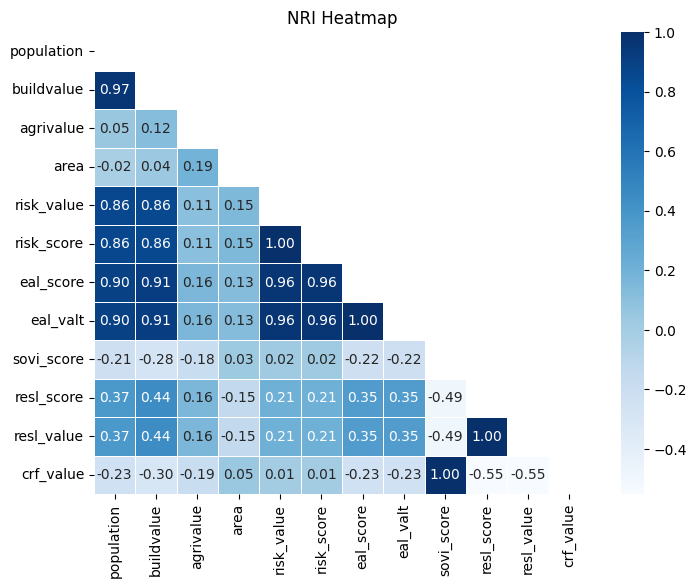

In [32]:
import numpy as np
correlation_matrix = nri_25.corr(method='spearman',numeric_only=True) # numeric_only=True to handle non-numeric columns
correlation_matrix

mask = np.ones_like(correlation_matrix, dtype=bool)
mask = np.triu(mask)
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=.5, mask=mask)
plt.title('NRI Heatmap')
plt.show()